In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from numpy.ma.core import indices
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix
from sklearn.datasets import make_classification
import pandas as pd
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier

np.random.seed(42)

In [3]:
df = pd.read_csv('../data/heart_disease_pca.csv')
df

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18,target
0,-1.222097,-2.147129,3.527468,3.515031,2.511901,-0.307260,3.306311,1.059299,-0.381307,0.334254,1.058640,-0.230813,-0.648257,1.456167,1.184890,-0.994618,-1.470792,-0.612920,0
1,-3.097091,-2.050521,-0.152794,-1.143146,-0.429758,0.546641,-0.603122,0.955910,2.047225,-0.498472,-0.388814,1.283165,-2.608038,-0.033722,-0.226652,0.568456,1.767201,0.452349,1
2,-3.888451,-0.046669,-0.730723,0.416922,-0.733631,0.750046,0.213373,-1.172223,-0.657454,-0.895567,-1.326810,-0.199718,0.905290,-0.395675,-0.788204,-1.043752,0.813360,-0.273336,1
3,1.711434,0.781108,3.279606,0.882589,1.383001,-0.507536,-0.871801,1.673405,-1.661097,0.086308,-2.158405,-1.241410,0.316015,1.451800,0.640511,1.185998,0.485683,1.140840,0
4,2.810397,-1.290863,0.219034,0.878665,-1.594360,0.270913,0.362685,0.440208,0.604565,0.581431,-0.799731,-0.770428,0.478469,-0.750515,-0.568474,0.853893,0.008441,-1.124430,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
292,-1.541735,1.793791,0.782796,-1.057477,-0.902581,0.830920,-1.065386,-0.916297,-0.006899,0.361029,1.533995,-0.368782,-0.699536,-0.498833,-0.420753,-0.033035,-0.571203,-1.149047,1
293,-0.308225,1.908923,1.814701,0.666549,0.062279,-1.101601,0.479187,-2.449384,0.315466,1.430153,-0.561630,1.629318,-0.239604,0.449058,1.564623,-1.204390,-0.768667,-0.539162,1
294,-3.050666,1.275985,-0.002431,0.489151,2.298940,1.815855,0.659553,-1.647685,0.029433,-1.233797,-0.828739,-0.687027,0.442288,-1.596993,-0.463491,-0.090073,-0.654498,1.405079,1
295,-2.735306,2.895983,-0.887450,-0.953583,-0.096321,-1.053433,1.001519,0.184723,-0.732206,0.624124,0.135519,0.100724,-0.788127,-1.214222,-0.923319,0.544032,-0.101692,-0.265043,1


In [4]:
x = df.drop('target', axis=1)
x

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18
0,-1.222097,-2.147129,3.527468,3.515031,2.511901,-0.307260,3.306311,1.059299,-0.381307,0.334254,1.058640,-0.230813,-0.648257,1.456167,1.184890,-0.994618,-1.470792,-0.612920
1,-3.097091,-2.050521,-0.152794,-1.143146,-0.429758,0.546641,-0.603122,0.955910,2.047225,-0.498472,-0.388814,1.283165,-2.608038,-0.033722,-0.226652,0.568456,1.767201,0.452349
2,-3.888451,-0.046669,-0.730723,0.416922,-0.733631,0.750046,0.213373,-1.172223,-0.657454,-0.895567,-1.326810,-0.199718,0.905290,-0.395675,-0.788204,-1.043752,0.813360,-0.273336
3,1.711434,0.781108,3.279606,0.882589,1.383001,-0.507536,-0.871801,1.673405,-1.661097,0.086308,-2.158405,-1.241410,0.316015,1.451800,0.640511,1.185998,0.485683,1.140840
4,2.810397,-1.290863,0.219034,0.878665,-1.594360,0.270913,0.362685,0.440208,0.604565,0.581431,-0.799731,-0.770428,0.478469,-0.750515,-0.568474,0.853893,0.008441,-1.124430
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
292,-1.541735,1.793791,0.782796,-1.057477,-0.902581,0.830920,-1.065386,-0.916297,-0.006899,0.361029,1.533995,-0.368782,-0.699536,-0.498833,-0.420753,-0.033035,-0.571203,-1.149047
293,-0.308225,1.908923,1.814701,0.666549,0.062279,-1.101601,0.479187,-2.449384,0.315466,1.430153,-0.561630,1.629318,-0.239604,0.449058,1.564623,-1.204390,-0.768667,-0.539162
294,-3.050666,1.275985,-0.002431,0.489151,2.298940,1.815855,0.659553,-1.647685,0.029433,-1.233797,-0.828739,-0.687027,0.442288,-1.596993,-0.463491,-0.090073,-0.654498,1.405079
295,-2.735306,2.895983,-0.887450,-0.953583,-0.096321,-1.053433,1.001519,0.184723,-0.732206,0.624124,0.135519,0.100724,-0.788127,-1.214222,-0.923319,0.544032,-0.101692,-0.265043


In [5]:
y = df['target']
y

0      0
1      1
2      1
3      0
4      0
      ..
292    1
293    1
294    1
295    1
296    1
Name: target, Length: 297, dtype: int64

In [6]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [7]:
rf_model = RandomForestClassifier(n_estimators=100,random_state=42)
rf_model.fit(x_train,y_train)
y_pred_rf = rf_model.predict(x_test)

# rfe = RFE(estimator=rf_model,n_features_to_select=10)
# rfe.fit(x_train,y_train)
# y_pred_rf = rfe.predict(x_test)

print(accuracy_score(y_test,rf_model.predict(x_test)))
print(classification_report(y_test,y_pred_rf))



0.8333333333333334
              precision    recall  f1-score   support

           0       0.86      0.86      0.86        36
           1       0.79      0.79      0.79        24

    accuracy                           0.83        60
   macro avg       0.83      0.83      0.83        60
weighted avg       0.83      0.83      0.83        60



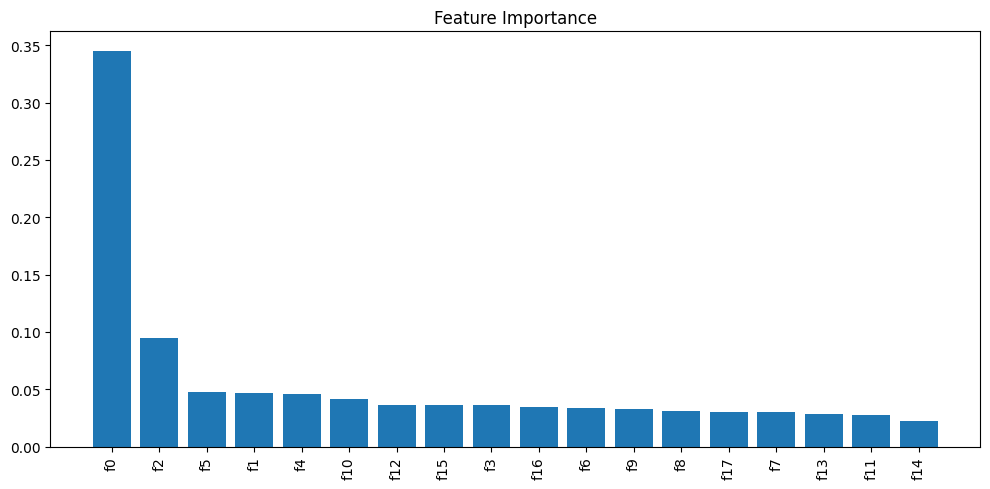

In [8]:
impotances = rf_model.feature_importances_
indices = np.argsort(impotances)[::-1]
plt.figure(figsize=(10,5))
plt.title("Feature Importance")
plt.bar(range(18),impotances[indices])
plt.xticks(range(18),[f'f{i}' for i in indices],rotation=90)
plt.tight_layout()
plt.show()

In [9]:
from sklearn.feature_selection import SelectKBest,chi2
from sklearn.preprocessing import MinMaxScaler

In [10]:
scaler = MinMaxScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)
k = 12
selector = SelectKBest(score_func=chi2, k=k)
x_train_selected = selector.fit_transform(x_train_scaled, y_train)
x_test_selected = selector.transform(x_test_scaled)

In [11]:
gb_model = GradientBoostingClassifier(n_estimators=100,learning_rate=0.1,random_state=42)

gb_model.fit(x_train_selected,y_train)
y_pred_gb = gb_model.predict(x_test_selected)
# gb_model.fit(x_train,y_train)
# y_pred_gb = gb_model.predict(x_test)

# rfe = RFE(estimator=gb_model,n_features_to_select=10)
# rfe.fit(x_train,y_train)
# y_pred_gb = rfe.predict(x_test)


print(accuracy_score(y_test,y_pred_gb))
print(classification_report(y_test,y_pred_gb))

0.8666666666666667
              precision    recall  f1-score   support

           0       0.91      0.86      0.89        36
           1       0.81      0.88      0.84        24

    accuracy                           0.87        60
   macro avg       0.86      0.87      0.86        60
weighted avg       0.87      0.87      0.87        60



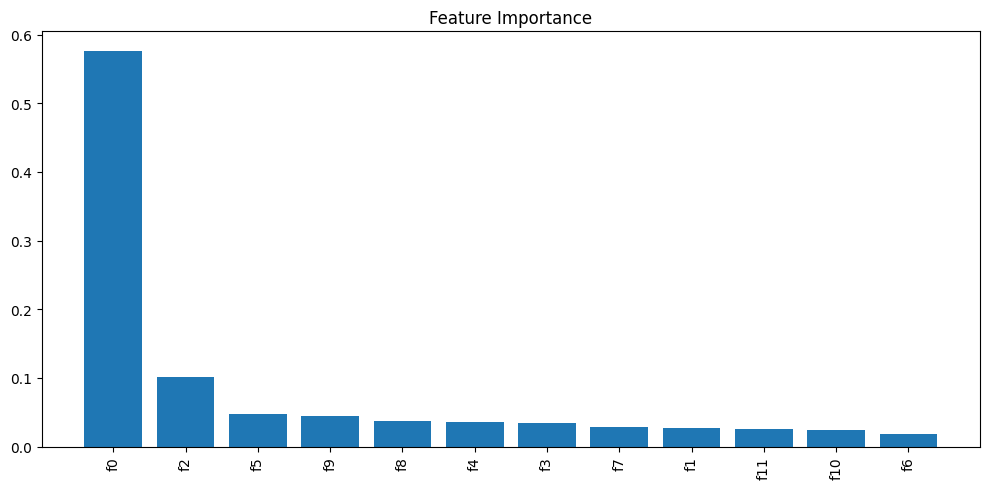

In [12]:
impotances = gb_model.feature_importances_
indices = np.argsort(impotances)[::-1]
plt.figure(figsize=(10,5))
plt.title("Feature Importance")
plt.bar(range(k),impotances[indices])
plt.xticks(range(k),[f'f{i}'for i in indices],rotation=90)
plt.tight_layout()
plt.show()

In [14]:
selected_columns = selector.get_feature_names_out().tolist()
selected_columns

['x0', 'x1', 'x2', 'x3', 'x4', 'x5', 'x8', 'x9', 'x10', 'x15', 'x16', 'x17']

In [15]:
train_df = pd.DataFrame(x_train_selected, columns=selected_columns)
train_df['target'] = y_train.values  # Ensure target is included
train_df.to_csv('../data/train_pca.csv', index=False)

test_df = pd.DataFrame(x_test_selected, columns=selected_columns)
test_df['target'] = y_test.values
test_df.to_csv('../data/test_pca.csv', index=False)